# Day 6: NumPy, Pandas, Matplotlib & Seaborn
### The Essential Data Science Stack for Machine Learning

**Topics covered:**
1. 🔢 NumPy — Arrays & Vectorized Operations
2. 🐼 Pandas — DataFrames & Data Cleaning
3. 📊 Matplotlib — Core Plotting
4. 🌊 Seaborn — Statistical Visualizations
5. 🔗 Putting It All Together — ML Dataset EDA

> **Dataset used:** Student Performance Dataset (generated to reflect real-world patterns)  
> For the full curriculum, visit **www.techvedhu.com**


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## ⚙️ Setup — Import Libraries & Generate Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Plot styling
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 100

print("✅ All libraries imported successfully!")
print(f"NumPy  version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

✅ All libraries imported successfully!
NumPy  version: 2.0.2
Pandas version: 2.2.2


---
## 1. 🔢 NumPy — Fast Numerical Computing

NumPy is the backbone of ML in Python. It provides **N-dimensional arrays** and **vectorized math** that replace slow Python loops.


In [ ]:
array = np.array([1,2,3,4,5,6])
print(array)
print(type(array))
print(array.shape)

[1 2 3 4 5 6]
<class 'numpy.ndarray'>
(6,)


In [ ]:
# Handling NaN (missing values) — critical in ML!
arr_with_nan = np.array([10, np.nan, 30, np.nan, 50])
print("With NaN:    ", arr_with_nan)
print("NaN-safe mean:", np.nanmean(arr_with_nan))
print("NaN-safe std: ", np.nanstd(arr_with_nan))

With NaN:     [10. nan 30. nan 50.]
NaN-safe mean: 30.0
NaN-safe std:  16.32993161855452


### 1.5 Array Reshaping & Stacking

In [ ]:
a = np.arange(12)
print("Original:", a)
print("Reshaped (3×4):\n", a.reshape(3, 4))
print("Flattened:", a.reshape(3, 4).flatten())

# Stacking arrays — useful for combining feature arrays
X1 = np.array([[1, 2], [3, 4]])
X2 = np.array([[5, 6], [7, 8]])
print("Vertical stack:\n", np.vstack([X1, X2]))
print("Horizontal stack:\n", np.hstack([X1, X2]))

Original: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Reshaped (3×4):
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
Flattened: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Vertical stack:
 [[1 2]
 [3 4]
 [5 6]
 [7 8]]
Horizontal stack:
 [[1 2 5 6]
 [3 4 7 8]]


---
## 2. 🐼 Pandas — Data Manipulation & Cleaning

Pandas provides the **DataFrame** — a 2D labeled table like an Excel sheet — that every ML project uses to load, clean, and prepare data.


### 2.1 Loading & Inspecting Data

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/AI/student_performance.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (200, 6)

First 5 rows:


,study_hours,attendance,prev_score,sleep_hours,tutoring,final_score
0,4.4,82.1,45.7,4.8,No,33.5
1,9.6,54.2,89.6,5.4,Yes,54.4
2,7.6,58.1,67.8,4.9,No,46.3
3,6.4,94.9,85.5,4.4,No,55.1
4,2.4,80.3,57.6,4.6,No,33.0


In [ ]:
# Quick data overview
print("Info:")
df.info()

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  190 non-null    float64
 1   attendance   200 non-null    float64
 2   prev_score   200 non-null    float64
 3   sleep_hours  192 non-null    float64
 4   tutoring     200 non-null    object 
 5   final_score  200 non-null    float64
dtypes: float64(5), object(1)
memory usage: 9.5+ KB


In [ ]:
print("Statistical Summary:")
df.describe()

Statistical Summary:


,study_hours,attendance,prev_score,sleep_hours,final_score
count,190.000000,200.00000,200.000000,192.000000,200.000000
mean,5.338947,75.21900,68.637500,6.406250,44.434500
std,2.655803,14.64782,16.898477,1.399874,10.166902
min,1.000000,50.30000,40.600000,4.100000,20.000000
25%,3.100000,63.10000,54.050000,5.200000,37.850000
50%,5.300000,77.05000,68.900000,6.400000,45.100000
75%,7.800000,87.07500,84.625000,7.700000,50.125000
max,9.900000,99.50000,95.000000,8.900000,73.600000


### 2.2 Handling Missing Values

In [ ]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values per column:
study_hours    10
attendance      0
prev_score      0
sleep_hours     8
tutoring        0
final_score     0
dtype: int64

Total missing: 18


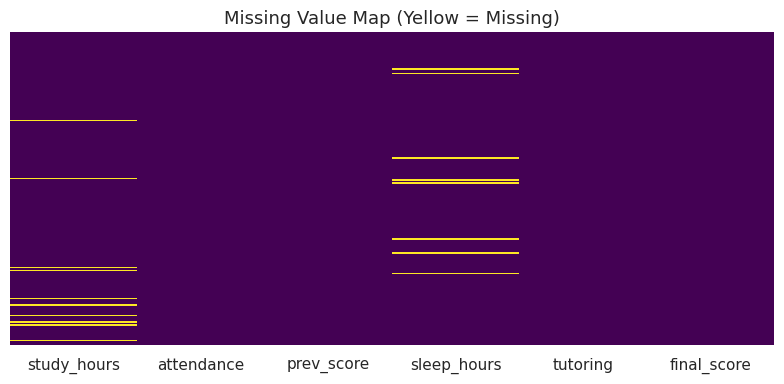

In [ ]:
# Visualise missing values
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Missing Value Map (Yellow = Missing)", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Filling missing values with median (robust to outliers)
df["study_hours"].fillna(df["study_hours"].median(), inplace=True)
df["sleep_hours"].fillna(df["sleep_hours"].median(), inplace=True)

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
study_hours    0
attendance     0
prev_score     0
sleep_hours    0
tutoring       0
final_score    0
dtype: int64


/tmp/ipykernel_3177/3134672776.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["study_hours"].fillna(df["study_hours"].median(), inplace=True)
/tmp/ipykernel_3177/3134672776.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

### 2.3 Selecting, Filtering & Sorting

In [ ]:
# Select a single column
print(df["final_score"].head())

# Select multiple columns
print(df[["study_hours", "final_score"]].head())

# Filter rows
high_scorers = df[df["final_score"] >= 85]
print(f"\nStudents with final_score ≥ 85: {len(high_scorers)}")
high_scorers.head()

0    33.5
1    54.4
2    46.3
3    55.1
4    33.0
Name: final_score, dtype: float64
   study_hours  final_score
0          4.4         33.5
1          9.6         54.4
2          7.6         46.3
3          6.4         55.1
4          2.4         33.0

Students with final_score ≥ 85: 0


,study_hours,attendance,prev_score,sleep_hours,tutoring,final_score


In [ ]:
# Filtering with multiple conditions
top_students = df[(df["study_hours"] >= 7) & (df["attendance"] >= 85)]
print(f"High study + high attendance: {len(top_students)} students")

# Sorting
df.sort_values("final_score", ascending=False).head()

High study + high attendance: 19 students


,study_hours,attendance,prev_score,sleep_hours,tutoring,final_score
67,8.2,85.1,87.8,4.8,Yes,73.6
140,9.7,74.6,92.5,6.3,Yes,71.1
88,9.0,64.3,92.3,7.8,Yes,65.8
12,8.5,82.6,92.3,7.1,Yes,65.2
73,8.3,95.7,89.0,6.6,No,65.2


### 2.4 Creating New Features (Feature Engineering)

In [ ]:
# New column: study efficiency index
df["study_efficiency"] = df["study_hours"] * (df["attendance"] / 100)

# Encode categorical column
df["tutoring_encoded"] = (df["tutoring"] == "Yes").astype(int)

# Binning scores into grade categories
df["grade"] = pd.cut(df["final_score"],
                     bins=[0, 40, 55, 70, 85, 100],
                     labels=["F", "D", "C", "B", "A"])

print(df[["study_hours", "study_efficiency", "tutoring_encoded", "grade"]].head(8))

   study_hours  study_efficiency  tutoring_encoded grade
0          4.4            3.6124                 0     F
1          9.6            5.2032                 1     D
2          7.6            4.4156                 0     D
3          6.4            6.0736                 0     C
4          2.4            1.9272                 0     F
5          2.4            1.2120                 0     D
6          1.5            0.8265                 0     F
7          8.8            7.3216                 0     D


### 2.5 GroupBy & Aggregation

In [ ]:
# Average final score by tutoring status
print("Avg score by tutoring:")
print(df.groupby("tutoring")["final_score"].mean().round(2))

print("\nGrade distribution:")
print(df["grade"].value_counts().sort_index())

# Multiple aggregations
summary = df.groupby("grade").agg(
    count=("final_score", "count"),
    avg_study=("study_hours", "mean"),
    avg_attendance=("attendance", "mean")
).round(2)
print("\nSummary by Grade:")
print(summary)

Avg score by tutoring:
tutoring
No     42.14
Yes    47.35
Name: final_score, dtype: float64

Grade distribution:
grade
F     67
D    105
C     26
B      2
A      0
Name: count, dtype: int64

Summary by Grade:
       count  avg_study  avg_attendance
grade                                  
F         67       3.65           71.93
D        105       5.68           76.42
C         26       8.02           78.52
B          2       8.95           79.85
A          0        NaN             NaN


/tmp/ipykernel_3177/270593927.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("grade").agg(


---
## 3. 📊 Matplotlib — Core Plotting

Matplotlib gives full control over every chart element. It's the foundation all other Python viz libraries build on.


### 3.1 Line Plot

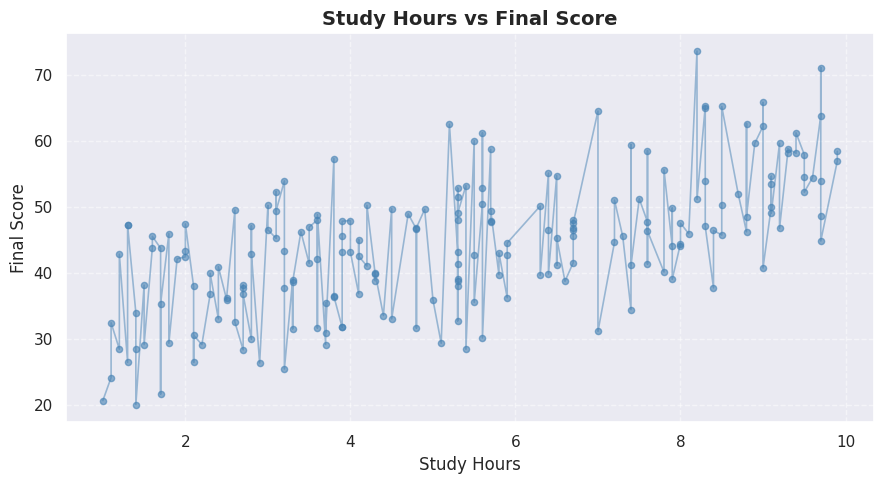

In [ ]:
students_sorted = df.sort_values("study_hours")

plt.figure(figsize=(9, 5))
plt.plot(students_sorted["study_hours"], students_sorted["final_score"],
         color="steelblue", alpha=0.5, linewidth=1.2)
plt.scatter(students_sorted["study_hours"], students_sorted["final_score"],
            color="steelblue", s=20, alpha=0.6)
plt.xlabel("Study Hours", fontsize=12)
plt.ylabel("Final Score", fontsize=12)
plt.title("Study Hours vs Final Score", fontsize=14, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### 3.2 Bar Chart

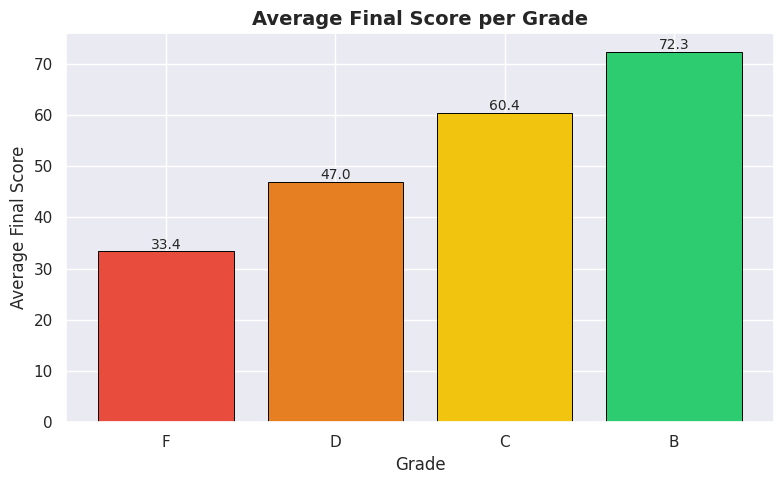

In [ ]:
grade_avg = df.groupby("grade", observed=True)["final_score"].mean()

plt.figure(figsize=(8, 5))
bars = plt.bar(grade_avg.index, grade_avg.values,
               color=["#e74c3c","#e67e22","#f1c40f","#2ecc71","#3498db"],
               edgecolor="black", linewidth=0.7)

for bar, val in zip(bars, grade_avg.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val:.1f}", ha="center", fontsize=10)

plt.xlabel("Grade", fontsize=12)
plt.ylabel("Average Final Score", fontsize=12)
plt.title("Average Final Score per Grade", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 3.3 Histogram

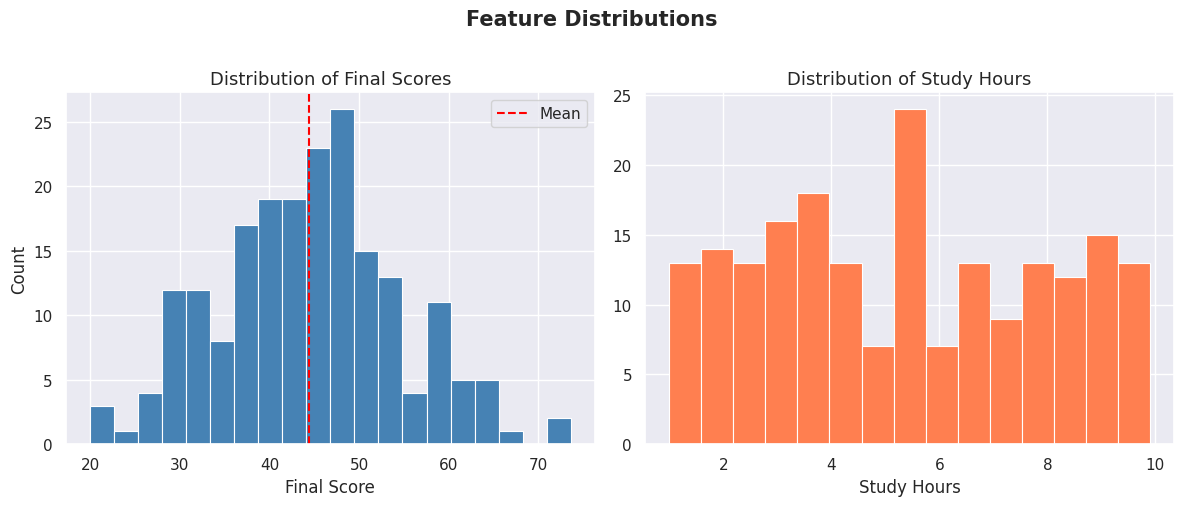

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["final_score"], bins=20, color="steelblue", edgecolor="white", linewidth=0.8)
axes[0].set_title("Distribution of Final Scores", fontsize=13)
axes[0].set_xlabel("Final Score")
axes[0].set_ylabel("Count")
axes[0].axvline(df["final_score"].mean(), color="red", linestyle="--", label="Mean")
axes[0].legend()

axes[1].hist(df["study_hours"], bins=15, color="coral", edgecolor="white", linewidth=0.8)
axes[1].set_title("Distribution of Study Hours", fontsize=13)
axes[1].set_xlabel("Study Hours")

plt.suptitle("Feature Distributions", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 3.4 Scatter Plot with Color Encoding

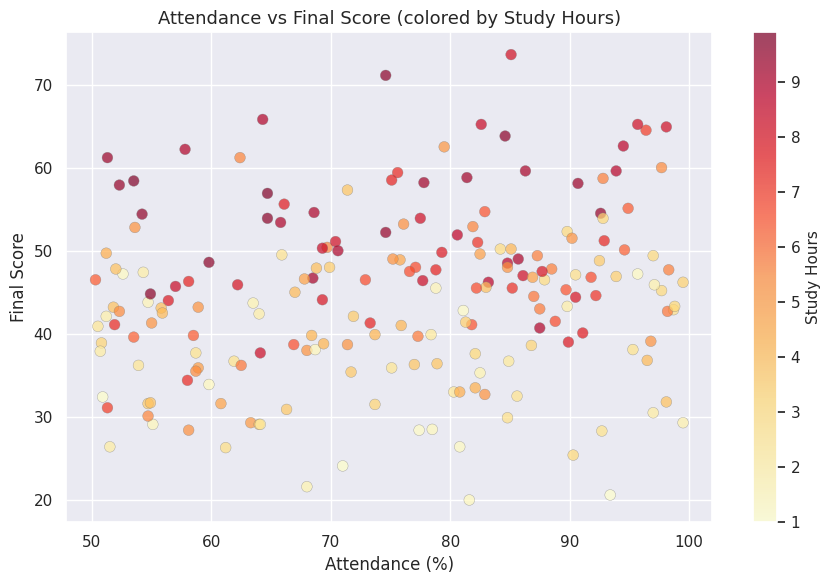

In [ ]:
plt.figure(figsize=(9, 6))
scatter = plt.scatter(df["attendance"], df["final_score"],
                      c=df["study_hours"], cmap="YlOrRd",
                      alpha=0.7, s=60, edgecolors="gray", linewidth=0.3)

cbar = plt.colorbar(scatter)
cbar.set_label("Study Hours", fontsize=11)
plt.xlabel("Attendance (%)", fontsize=12)
plt.ylabel("Final Score", fontsize=12)
plt.title("Attendance vs Final Score (colored by Study Hours)", fontsize=13)
plt.tight_layout()
plt.show()

---
## 4. 🌊 Seaborn — Statistical Data Visualization

Seaborn builds on Matplotlib to produce beautiful statistical plots with less code. It integrates directly with Pandas DataFrames.


### 4.1 Distribution Plot

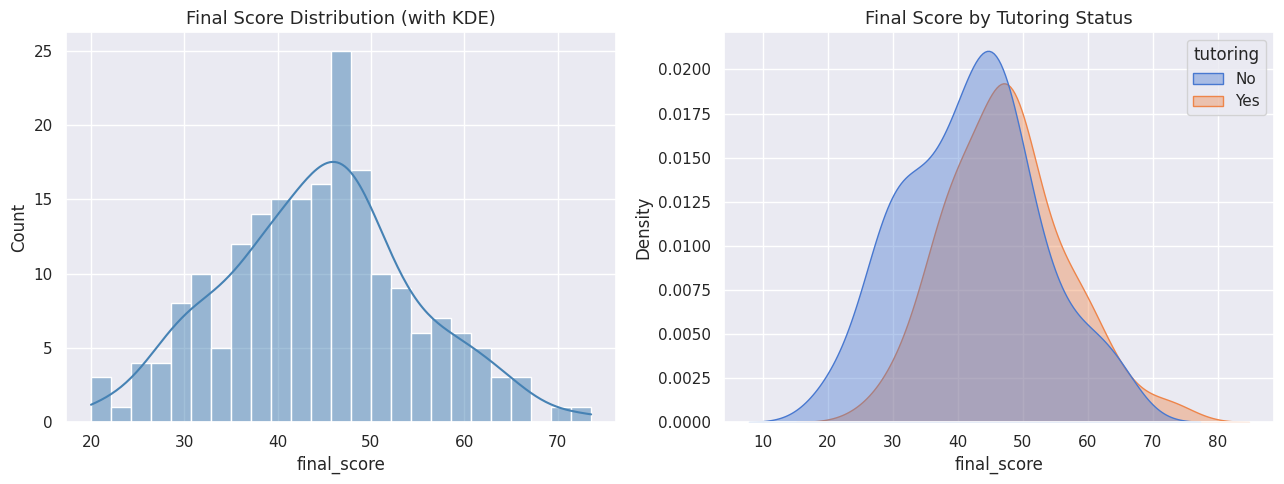

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df["final_score"], kde=True, ax=axes[0], color="steelblue", bins=25)
axes[0].set_title("Final Score Distribution (with KDE)", fontsize=13)

sns.kdeplot(data=df, x="final_score", hue="tutoring", fill=True, alpha=0.4, ax=axes[1])
axes[1].set_title("Final Score by Tutoring Status", fontsize=13)

plt.tight_layout()
plt.show()

### 4.2 Box Plot — Spotting Outliers

/tmp/ipykernel_3177/3470695492.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="grade", y="final_score", palette="Set2",
/tmp/ipykernel_3177/3470695492.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="tutoring", y="final_score", palette="Set1", ax=axes[1])


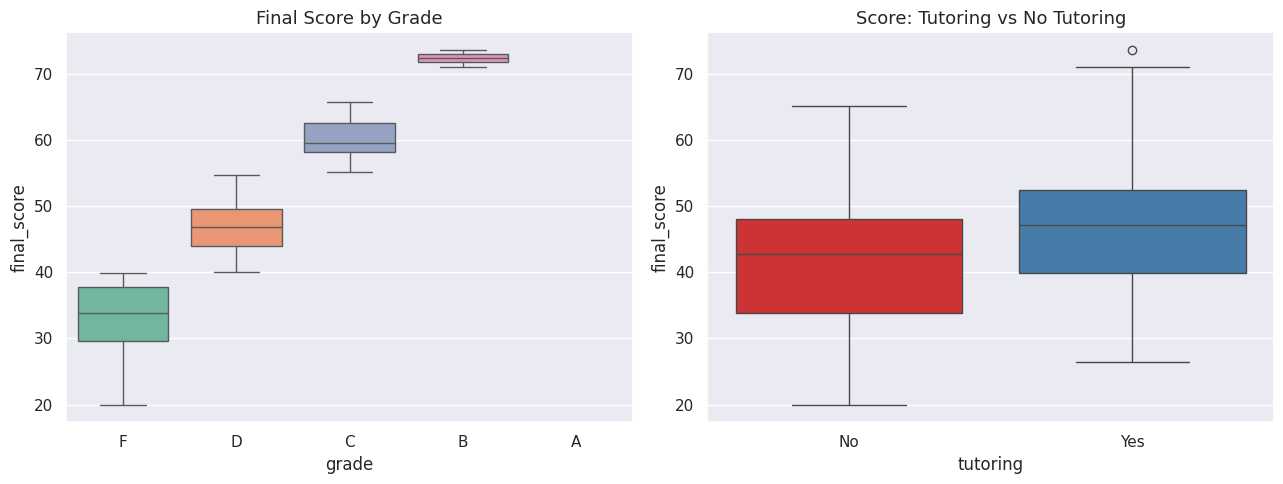

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x="grade", y="final_score", palette="Set2",
            order=["F","D","C","B","A"], ax=axes[0])
axes[0].set_title("Final Score by Grade", fontsize=13)

sns.boxplot(data=df, x="tutoring", y="final_score", palette="Set1", ax=axes[1])
axes[1].set_title("Score: Tutoring vs No Tutoring", fontsize=13)

plt.tight_layout()
plt.show()

### 4.3 Correlation Heatmap — Feature Relationships

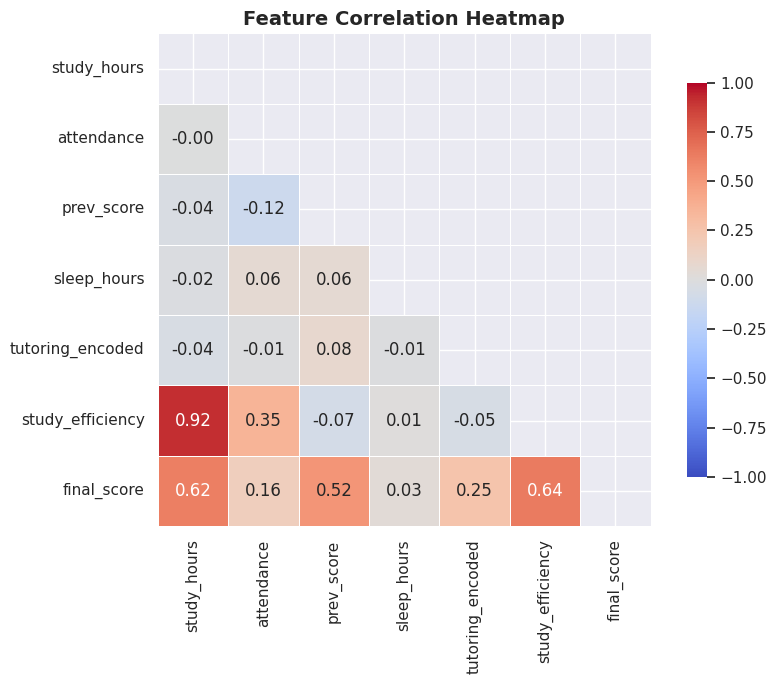

In [ ]:
numeric_cols = ["study_hours","attendance","prev_score","sleep_hours",
                "tutoring_encoded","study_efficiency","final_score"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            mask=mask, vmin=-1, vmax=1,
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 4.4 Pairplot — Multi-Feature Overview

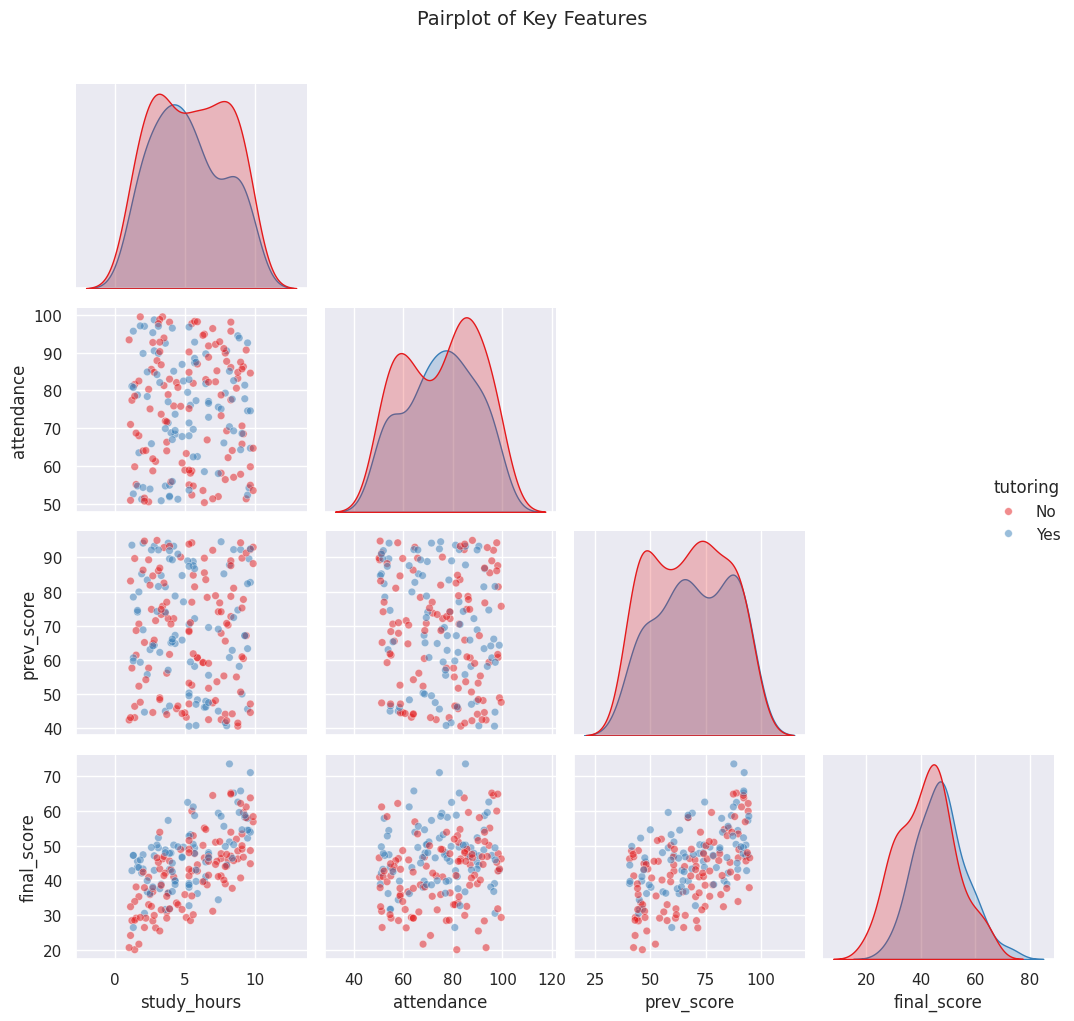

In [ ]:
# Select key columns to avoid clutter
pair_cols = ["study_hours", "attendance", "prev_score", "final_score", "tutoring"]
sns.pairplot(df[pair_cols], hue="tutoring", palette="Set1",
             plot_kws={"alpha": 0.5, "s": 30},
             diag_kind="kde", corner=True)
plt.suptitle("Pairplot of Key Features", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### 4.5 Bar Plot with Confidence Intervals

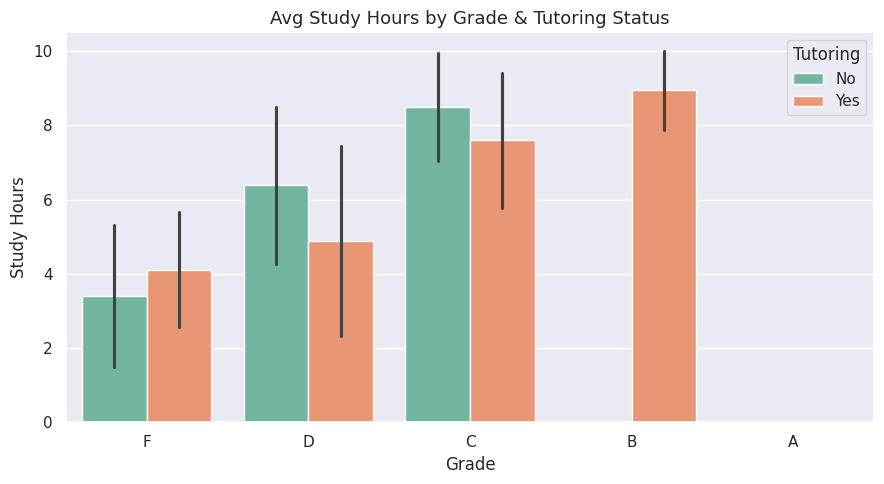

In [ ]:
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="grade", y="study_hours", hue="tutoring",
            order=["F","D","C","B","A"], palette="Set2", errorbar="sd")
plt.title("Avg Study Hours by Grade & Tutoring Status", fontsize=13)
plt.xlabel("Grade")
plt.ylabel("Study Hours")
plt.legend(title="Tutoring")
plt.tight_layout()
plt.show()

### 4.6 Violin Plot

/tmp/ipykernel_3177/3625234487.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="grade", y="final_score", palette="muted",


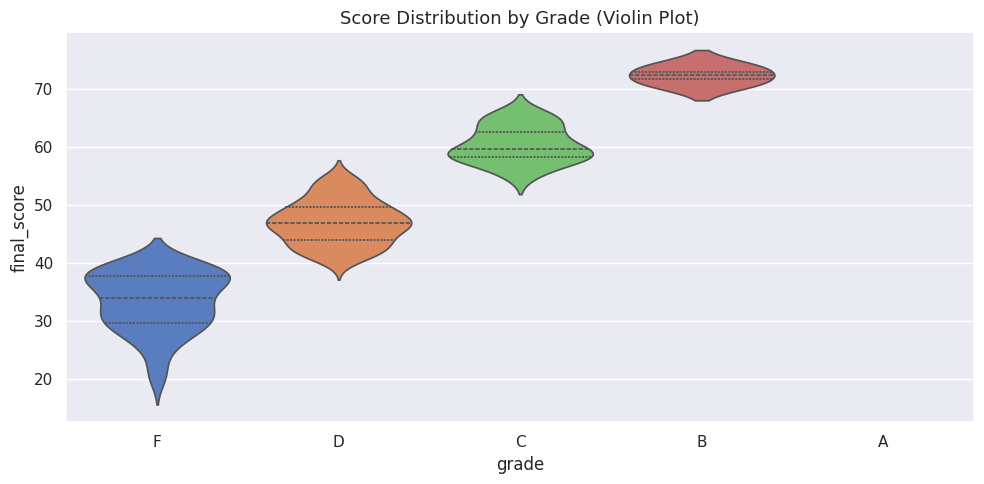

In [ ]:
plt.figure(figsize=(10, 5))
sns.violinplot(data=df, x="grade", y="final_score", palette="muted",
               order=["F","D","C","B","A"], inner="quartile")
plt.title("Score Distribution by Grade (Violin Plot)", fontsize=13)
plt.tight_layout()
plt.show()

---
## 5. 🔗 Putting It All Together — Full ML EDA Workflow

This section shows how a real ML project starts: loading data → cleaning → exploring → visualizing.


In [ ]:
# Step 1: Load & inspect
df_eda = pd.read_csv("/content/drive/MyDrive/AI/student_performance.csv")
print("Shape:", df_eda.shape)
print("\nMissing:")
print(df_eda.isnull().sum())

Shape: (200, 6)

Missing:
study_hours    10
attendance      0
prev_score      0
sleep_hours     8
tutoring        0
final_score     0
dtype: int64


In [ ]:
# Step 2: Clean
df_eda["study_hours"].fillna(df_eda["study_hours"].median(), inplace=True)
df_eda["sleep_hours"].fillna(df_eda["sleep_hours"].median(), inplace=True)

# Step 3: Feature engineering
df_eda["tutoring_encoded"] = (df_eda["tutoring"] == "Yes").astype(int)
df_eda["grade"] = pd.cut(df_eda["final_score"],
                          bins=[0,40,55,70,85,100],
                          labels=["F","D","C","B","A"])

print("✅ Data cleaned and features engineered")
df_eda.head()

✅ Data cleaned and features engineered


/tmp/ipykernel_3177/3034685833.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_eda["study_hours"].fillna(df_eda["study_hours"].median(), inplace=True)
/tmp/ipykernel_3177/3034685833.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(v

,study_hours,attendance,prev_score,sleep_hours,tutoring,final_score,tutoring_encoded,grade
0,4.4,82.1,45.7,4.8,No,33.5,0,F
1,9.6,54.2,89.6,5.4,Yes,54.4,1,D
2,7.6,58.1,67.8,4.9,No,46.3,0,D
3,6.4,94.9,85.5,4.4,No,55.1,0,C
4,2.4,80.3,57.6,4.6,No,33.0,0,F


In [ ]:
# Step 4: Statistical summary per group
print(df_eda.groupby("tutoring")[["study_hours","attendance","final_score"]].mean().round(2))

          study_hours  attendance  final_score
tutoring                                      
No               5.44       75.38        42.14
Yes              5.21       75.02        47.35


/tmp/ipykernel_3177/497701071.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x="tutoring", y="final_score", palette="Set1", ax=ax5)


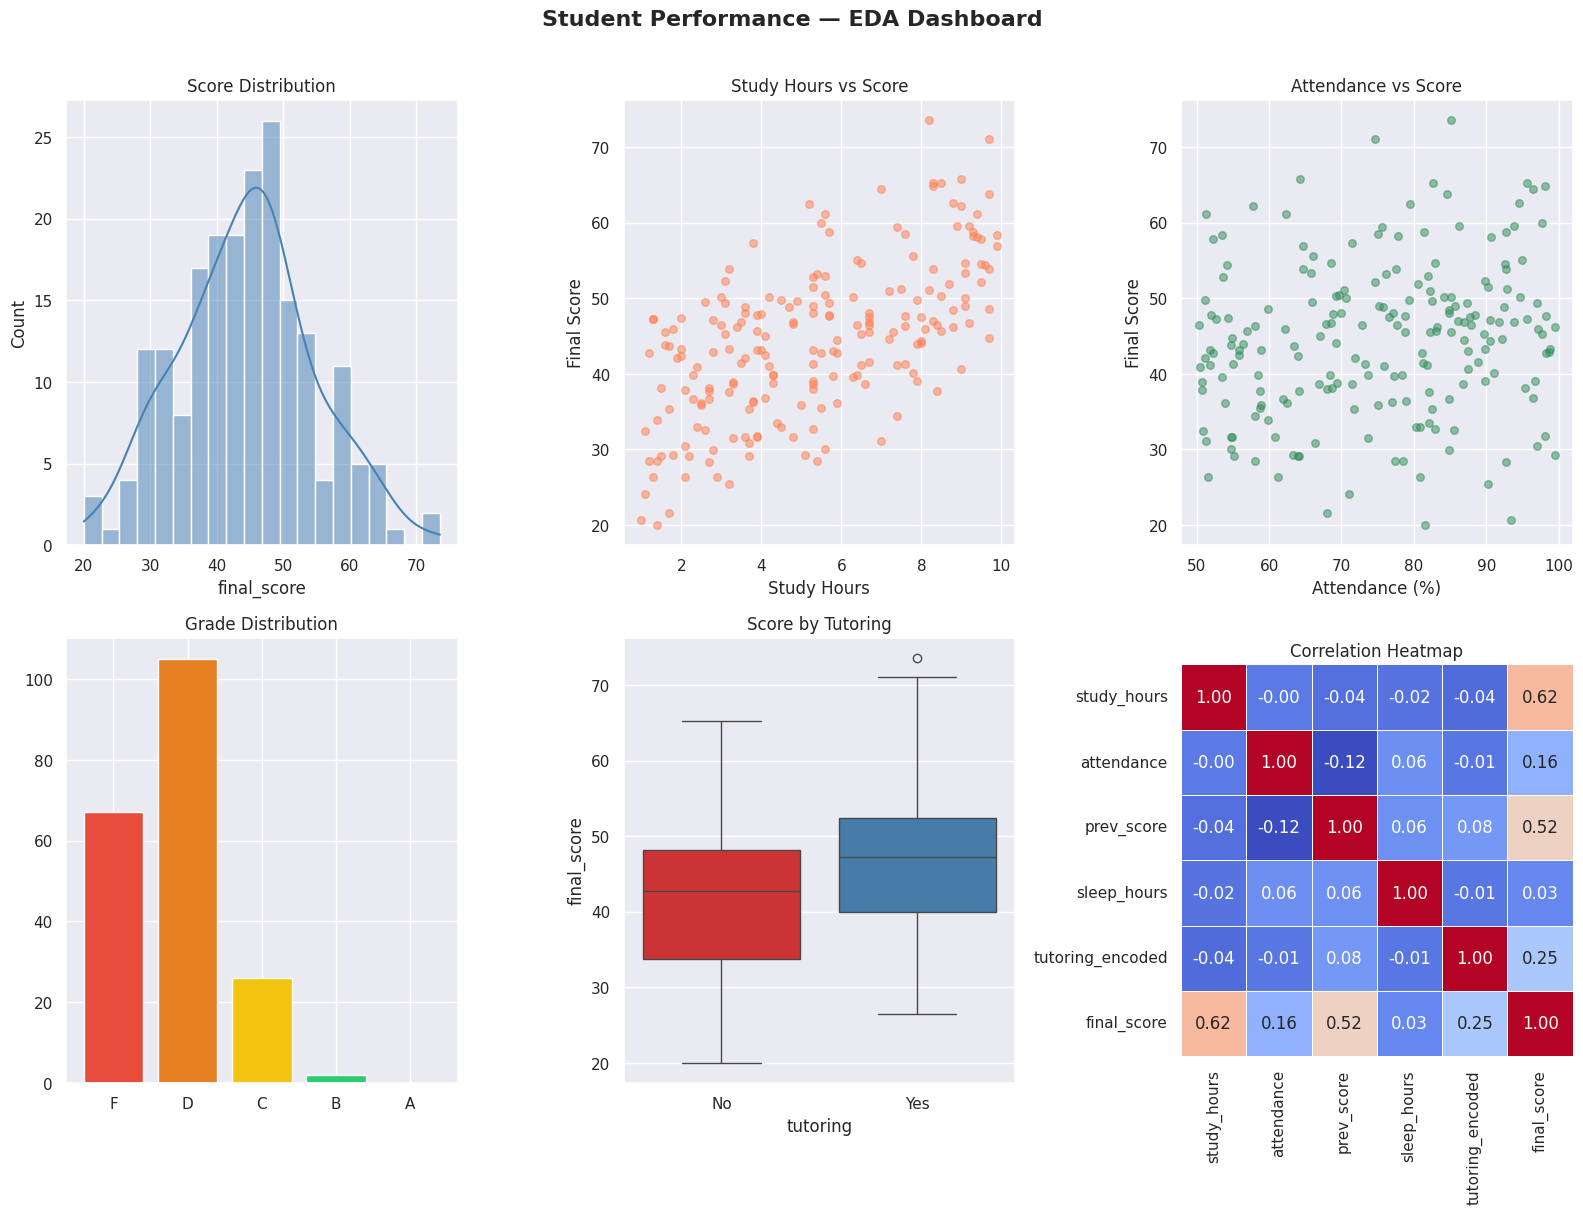


✅ EDA Dashboard complete!


In [ ]:
# Step 5: Full EDA Dashboard
fig = plt.figure(figsize=(16, 12))
fig.suptitle("Student Performance — EDA Dashboard", fontsize=16, fontweight="bold", y=1.01)

# Score distribution
ax1 = fig.add_subplot(2, 3, 1)
sns.histplot(df_eda["final_score"], kde=True, ax=ax1, color="steelblue", bins=20)
ax1.set_title("Score Distribution")

# Study hours vs score
ax2 = fig.add_subplot(2, 3, 2)
ax2.scatter(df_eda["study_hours"], df_eda["final_score"], alpha=0.5, color="coral", s=30)
ax2.set_xlabel("Study Hours")
ax2.set_ylabel("Final Score")
ax2.set_title("Study Hours vs Score")

# Attendance vs score
ax3 = fig.add_subplot(2, 3, 3)
ax3.scatter(df_eda["attendance"], df_eda["final_score"], alpha=0.5, color="seagreen", s=30)
ax3.set_xlabel("Attendance (%)")
ax3.set_ylabel("Final Score")
ax3.set_title("Attendance vs Score")

# Grade distribution
ax4 = fig.add_subplot(2, 3, 4)
grade_counts = df_eda["grade"].value_counts().sort_index()
ax4.bar(grade_counts.index, grade_counts.values,
        color=["#e74c3c","#e67e22","#f1c40f","#2ecc71","#3498db"])
ax4.set_title("Grade Distribution")

# Box: score by tutoring
ax5 = fig.add_subplot(2, 3, 5)
sns.boxplot(data=df_eda, x="tutoring", y="final_score", palette="Set1", ax=ax5)
ax5.set_title("Score by Tutoring")

# Correlation heatmap
ax6 = fig.add_subplot(2, 3, 6)
num_cols = ["study_hours","attendance","prev_score","sleep_hours","tutoring_encoded","final_score"]
corr = df_eda[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            ax=ax6, cbar=False, linewidths=0.5, square=True)
ax6.set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()

print("\n✅ EDA Dashboard complete!")

---
## 6. 🧪 Practice Exercises

1. **NumPy:** From `final_score` column, convert it to a NumPy array. Compute mean, std, and manually normalize it between 0 and 1.
2. **Pandas:** Filter students with `attendance < 60` AND `final_score > 75`. How many such students exist? What does that tell you?
3. **Pandas:** Use `groupby` to find the average `sleep_hours` per `grade`. Which grade sleeps the most?
4. **Matplotlib:** Plot a bar chart of the count of students per `grade`. Add value labels on top of each bar.
5. **Seaborn:** Plot a heatmap showing the correlation of only `study_hours`, `prev_score`, and `final_score`. Which two features are most correlated?


In [ ]:
# Exercise 1: NumPy normalization
scores_array = df["final_score"].to_numpy()
# Your code here


In [ ]:
# Exercise 2: Filter low attendance + high score
result = df[(df["attendance"] < 60) & (df["final_score"] > 75)]
print(f"Count: {len(result)}")


Count: 0


In [ ]:
# Exercise 3: Sleep hours per grade
# Your code here


In [ ]:
# Exercise 4: Bar chart with labels
grade_counts = df["grade"].value_counts().sort_index()
# Your code here


In [ ]:
# Exercise 5: Small correlation heatmap
cols = ["study_hours", "prev_score", "final_score"]
# Your code here


---
## ✅ Summary

| Library | Purpose in ML |
|---|---|
| **NumPy** | Fast array math, vectorized ops, no-loop computation |
| **Pandas** | Load, clean, filter, engineer features from tabular data |
| **Matplotlib** | Full-control charts: line, bar, scatter, histogram |
| **Seaborn** | Statistical plots: heatmaps, violin, pairplot, KDE |

**Tomorrow (Day 6):** Concept Learning — Hypothesis space, Find-S, and Candidate Elimination.

For the full curriculum, visit **www.techvedhu.com**
